# Inflow and Outflow Hydrograph Simulation

Equations:

$$I(t) = \frac{I_p}{2}\left[1-\cos(\alpha t)\right]e^{kt}$$

$$O(t) = \frac{1}{e^{kt}}\int_0^t k \, I(t)\, e^{kt}\, dt$$

$$\alpha = \frac{2\pi}{\tau}$$

where:
- **Ip** = Peak Discharge (m3/s)
- **thau (τ)** = Time base (hr)
- **k** = storage/routing coefficient
- **dt** = time step (hr)



In [ ]:
!pip install ipywidgets -q

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider
from IPython.display import display

In [2]:
def inflow_outflow_hydrograph(t, Ip, thau, k):
    """
    Computes I(t) and O(t) based on the formula.
    t     : time array (hr)
    Ip    : Peak Discharge (m3/s)
    thau  : Time base (hr)
    k     : routing coefficient

    The raw shape (1-cos(alpha*t)) * e^(k*t) is normalized so that
    its maximum equals Ip exactly -- this guarantees the inflow peak
    always matches the Peak Discharge input, regardless of k or thau.

    Because (1-cos(alpha*t)) is periodic, the raw shape would swing
    back up again for t > thau (unphysical). The hydrograph is only
    defined over one period [0, thau], so I(t) is forced to 0 beyond
    the time base -- this is what makes the inflow correctly stop
    instead of spiking again later on the time axis.
    """
    alpha = 2 * np.pi / thau

    # Raw shape from the formula (unscaled), valid only within [0, thau]
    shape = np.where(t <= thau, (1 - np.cos(alpha * t)) * np.exp(k * t), 0.0)

    # Inflow hydrograph I(t), scaled so max(I) = Ip
    I = Ip * shape / shape.max()

    # Outflow hydrograph O(t) = (1/e^(kt)) * integral(k * I(t) * e^(kt) dt)
    integrand = k * I * np.exp(k * t)
    integral = cumulative_trapezoid(integrand, t, initial=0)
    O = integral / np.exp(k * t)

    return I, O, alpha

In [35]:
def plot_hydrograph(Ip=60, thau=3.8, k=1.8, dt=0.05, t_end=4.0, review_time=2.85):
    t = np.arange(0, t_end + dt, dt)
    I, O, alpha = inflow_outflow_hydrograph(t, Ip, thau, k)

    # Point at the selected review time (like the 'Time' marker in Excel)
    idx = (np.abs(t - review_time)).argmin()
    t_point = t[idx]
    I_point = I[idx]
    O_point = O[idx]

    # Peak of each curve
    idx_Ipeak = np.argmax(I)
    idx_Opeak = np.argmax(O)

    plt.figure(figsize=(9, 5))
    plt.plot(t, I, label='I(t) - Inflow', color='tab:blue')
    plt.plot(t, O, label='O(t) - Outflow', color='tab:orange')

    plt.scatter([t_point], [I_point], color='blue', zorder=5, label=f'Point I(t) = {I_point:.2f}')
    plt.scatter([t_point], [O_point], color='red', zorder=5, label=f'Point O(t) = {O_point:.2f}')

    plt.annotate('Inflow', xy=(t[idx_Ipeak], I[idx_Ipeak]), xytext=(t[idx_Ipeak]-0.4, I[idx_Ipeak]-3))
    plt.annotate('Outflow', xy=(t[idx_Opeak], O[idx_Opeak]), xytext=(t[idx_Opeak]+0.2, O[idx_Opeak]-3))

    plt.xlabel('Time (hr)')
    plt.ylabel('Q (m3/s)')
    plt.title(f'Inflow and Outflow Hydrograph | Time = {t_point:.2f} hr')
    plt.grid(alpha=0.3)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig('hydrograph_plot.jpg', format='jpg', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    print(f"Alpha (α) = 2π/τ = {alpha:.3f}")
    print(f"At t = {t_point:.2f} hr -> I(t) = {I_point:.2f} m3/s ; O(t) = {O_point:.2f} m3/s")
    print(f"Peak Inflow  = {I[idx_Ipeak]:.2f} m3/s at t = {t[idx_Ipeak]:.2f} hr")
    print(f"Peak Outflow = {O[idx_Opeak]:.2f} m3/s at t = {t[idx_Opeak]:.2f} hr")





## Static simulation

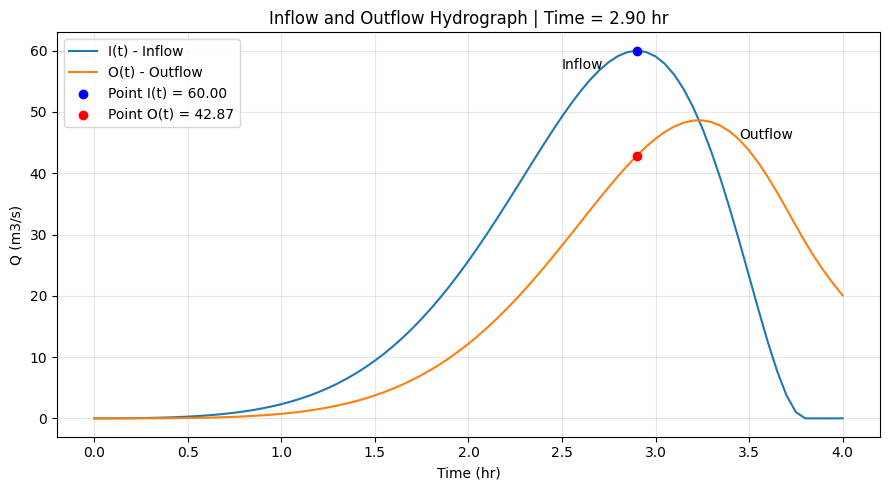

Alpha (α) = 2π/τ = 1.653
At t = 2.90 hr -> I(t) = 60.00 m3/s ; O(t) = 42.87 m3/s
Peak Inflow  = 60.00 m3/s at t = 2.90 hr
Peak Outflow = 48.64 m3/s at t = 3.25 hr


In [40]:
plot_hydrograph(
    Ip=60,
    thau=3.8,
    k=1.8,
    dt=0.05,
    t_end=4.0,
    review_time=2.9)

## Interactive simulation
Move the sliders to change Ip, thau (τ), k, and the review time.

In [15]:
interact(
    plot_hydrograph,
    Ip=FloatSlider(value=60, min=10, max=200, step=1, description='Ip (Peak Q)'),
    thau=FloatSlider(value=3.8, min=1, max=10, step=0.1, description='thau (τ)'),
    k=FloatSlider(value=1.8, min=0.1, max=5, step=0.1, description='k'),
    dt=FloatSlider(value=0.05, min=0.01, max=0.2, step=0.01, description='dt'),
    t_end=widgets.fixed(4.0),
    review_time=FloatSlider(value=2.9, min=0, max=10, step=0.05, description='Review time')
);

interactive(children=(FloatSlider(value=60.0, description='Ip (Peak Q)', max=200.0, min=10.0, step=1.0), Float…

In [25]:
from google.colab import files

# Simpan gambar
plt.savefig('hydrograph_plot.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

# Download otomatis ke komputer
files.download('hydrograph_plot.jpg')

<Figure size 640x480 with 0 Axes>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>